# Notebook 02 — Apply SmoothQuant + W8A8 Fake-Quant, Verify with Perplexity

This is the first notebook where we actually do SmoothQuant. Notebook 01 collected activation scales; this notebook uses those scales to transform the model and then fake-quantizes it to W8A8.

We validate on **WikiText-2 perplexity** rather than jumping straight to HumanEval because:

- Perplexity is fast (~1-2 min per configuration)
- It catches catastrophic quantization failures immediately
- HumanEval takes 25+ min per config; we don't want to burn that compute only to find the smoothed model is broken

## The four configurations we measure

| Config | What it tests |
|---|---|
| **bf16 baseline** | Reference perplexity |
| **W8A8, no smoothing** | Shows the problem SmoothQuant solves — naive W8A8 should be visibly worse |
| **SmoothQuant(α=0.5) + W8A8** | The paper's solution — should be close to bf16 |
| **SmoothQuant(α=0.85) + W8A8** | Paper's OPT alpha; lets us start the ablation |

The key paper claim we're verifying: **the smoothed W8A8 model matches the bf16 baseline within ~0.1 perplexity, while naive W8A8 is multiple points worse.**

## Outputs

- `results/ppl_<model_size>.csv` — perplexity for all four configs
- `checkpoints/qwen25-coder-<size>-smoothed-a<alpha>/` — smoothed bf16 model, ready for notebook 03 (real INT8 export) and notebooks 04/05 (benchmarks)

## Runtime

- **7B on A100**: ~12 min total (3 model loads + 4 PPL evals)
- **7B on L4**: ~18 min total
- **14B on A100 40GB**: ~25 min — L4 cannot hold 14B bf16

## Section 1 — Setup

In [1]:
import os, sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/qwen-smoothquant-project'
    assert os.path.exists(PROJECT_ROOT), f'Project not found at {PROJECT_ROOT}'
    %cd $PROJECT_ROOT
except ImportError:
    PROJECT_ROOT = os.getcwd()
    assert os.path.exists('src/qwen_smooth.py')

if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
/content/drive/MyDrive/qwen-smoothquant-project
Project root: /content/drive/MyDrive/qwen-smoothquant-project


In [2]:
# Install deps (skip if already installed in this session)
!pip install -q transformers accelerate datasets tqdm

In [3]:
import os
for d in ['results', 'results/plots', 'checkpoints']:
    os.makedirs(d, exist_ok=True)
print('Output dirs ready.')

Output dirs ready.


In [4]:
# Configuration
MODEL_SIZE = '7B'                # '7B' or '14B'
MODEL_ID   = f'Qwen/Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
ACT_SCALES_PATH = f'act_scales/qwen25-coder-{MODEL_SIZE.lower()}.pt'
ALPHAS_TO_TEST  = [0.5, 0.85]   # alpha=0.5 is the main config; 0.85 starts the ablation
SAVE_ALPHA      = 0.5           # which smoothed checkpoint to save for downstream notebooks
PPL_SEQ_LEN     = 2048          # sequence length for perplexity (standard WikiText chunk size)

assert os.path.exists(ACT_SCALES_PATH), (
    f'Missing {ACT_SCALES_PATH}. Run notebook 01 first.'
)

print(f'Model:     {MODEL_ID}')
print(f'Scales:    {ACT_SCALES_PATH}')
print(f'Alphas:    {ALPHAS_TO_TEST}')

Model:     Qwen/Qwen2.5-Coder-7B-Instruct
Scales:    act_scales/qwen25-coder-7b.pt
Alphas:    [0.5, 0.85]


In [5]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader

NVIDIA A100-SXM4-80GB, 81920 MiB, 0 MiB


## Section 2 — Perplexity evaluator

Standard WikiText-2 chunked perplexity: concatenate the test set into a single token stream, split into non-overlapping chunks of `seq_len` tokens, compute cross-entropy on each, then report `exp(mean_loss)`.

This matches the evaluation in the upstream `smoothquant/ppl_eval.py` so our numbers are comparable to the paper's.

In [6]:
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm import tqdm


@torch.no_grad()
def evaluate_perplexity(model, tokenizer, seq_len=2048, stride=None):
    """Chunked perplexity on WikiText-2 test set."""
    model.eval()
    device = next(model.parameters()).device
    stride = stride or seq_len

    # Load and concatenate the full test set — standard practice for LLM PPL
    data = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
    text = '\n\n'.join(data['text'])
    enc = tokenizer(text, return_tensors='pt')
    input_ids = enc.input_ids.to(device)
    n_tokens = input_ids.size(1)

    nlls = []            # per-chunk total NLL (sum, not mean)
    total_tokens = 0     # count of tokens where we actually computed loss
    for begin in tqdm(range(0, n_tokens - 1, stride), desc='PPL', leave=False):
        end = min(begin + seq_len, n_tokens)
        chunk = input_ids[:, begin:end]
        if chunk.size(1) < 2:
            break
        # Target is chunk shifted by one; HF loss handles the shift internally.
        labels = chunk.clone()
        outputs = model(chunk, labels=labels)
        # outputs.loss is mean CE over (chunk.size(1) - 1) predicted tokens.
        # Multiply by token count to recover total NLL; we'll divide by the
        # overall total after the loop.
        n_pred = chunk.size(1) - 1
        nlls.append(outputs.loss.float() * n_pred)
        total_tokens += n_pred

    mean_nll = torch.stack(nlls).sum() / total_tokens
    return torch.exp(mean_nll).item()


def free_model(model):
    """Aggressively release a model's GPU memory."""
    import gc
    del model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print('Evaluator ready.')

Evaluator ready.


## Section 3 — Config 1: bf16 baseline

Reference point. This is the "unquantized" perplexity we're trying to match.

In [7]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Configuration variables needed for this cell, likely defined in a previous cell.
# Added here to make this cell self-contained and resolve NameError.
MODEL_SIZE = '7B'
MODEL_ID   = f'Qwen/Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
PPL_SEQ_LEN = 2048

results = {}   # config name -> perplexity

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print('Loading bf16 baseline...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto'
)
model.eval()

print('Measuring bf16 perplexity...')
ppl_bf16 = evaluate_perplexity(model, tokenizer, seq_len=PPL_SEQ_LEN)
results['bf16_baseline'] = ppl_bf16
print(f'  bf16 baseline PPL: {ppl_bf16:.4f}')

free_model(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 32768). Running this sequence through the model will result in indexing errors


  bf16 baseline PPL: 9.5519


## Section 4 — Config 2: W8A8 without smoothing (the problem)

This is what happens when you do the naive thing: replace every `nn.Linear` with a W8A8 fake-quant version, with no outlier handling. The paper's central claim is that this degrades accuracy significantly. For Llama-family models that typically means a 0.3-1.0 point perplexity increase — small in absolute terms but visible.

If you don't see a gap between this and the smoothed version, something's wrong (either the calibration scales are off, or the alphas are too small to matter).

In [8]:
from src.qwen_fake_quant import quantize_qwen2_w8a8

print('Loading bf16 for naive W8A8...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto'
)
model.eval()

print('Replacing Linears with W8A8 fake-quant (no smoothing applied)...')
quantize_qwen2_w8a8(model)

print('Measuring naive W8A8 perplexity...')
ppl_naive_w8a8 = evaluate_perplexity(model, tokenizer, seq_len=PPL_SEQ_LEN)
results['w8a8_no_smooth'] = ppl_naive_w8a8
print(f'  W8A8 (no smoothing) PPL: {ppl_naive_w8a8:.4f}')
print(f'  Degradation vs bf16:     {ppl_naive_w8a8 - ppl_bf16:+.4f}')

free_model(model)

Loading bf16 for naive W8A8...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Replacing Linears with W8A8 fake-quant (no smoothing applied)...
Replaced 196 Linears with W8A8Linear (fake-quant)
Measuring naive W8A8 perplexity...


  W8A8 (no smoothing) PPL: 9.6328
  Degradation vs bf16:     +0.0809


## Section 5 — Configs 3 & 4: SmoothQuant + W8A8 at different alphas

Now the actual SmoothQuant pipeline. For each alpha we:

1. Load a fresh bf16 model
2. Apply smoothing in-place using the calibrated scales
3. (For `SAVE_ALPHA` only) Save the smoothed bf16 checkpoint to disk — notebook 03 (real INT8 export) and notebooks 04/05 (benchmarks) reload from this
4. Replace Linears with W8A8 fake-quant
5. Measure perplexity

Note that saving happens BEFORE fake-quant. The checkpoint stores the smoothed bf16 weights, not the quantized ones — you can always re-quantize at load time.

In [9]:
from src.qwen_smooth import smooth_qwen2
from src.calibrate import load_act_scales

act_scales = load_act_scales(ACT_SCALES_PATH)

Loaded 197 act_scales from act_scales/qwen25-coder-7b.pt


In [10]:
for alpha in ALPHAS_TO_TEST:
    print('=' * 60)
    print(f'Config: SmoothQuant(alpha={alpha}) + W8A8')
    print('=' * 60)

    print(f'Loading fresh bf16 model for alpha={alpha}...')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.bfloat16, device_map='auto'
    )
    model.eval()

    print(f'Applying SmoothQuant (alpha={alpha})...')
    smooth_qwen2(model, act_scales, alpha=alpha)

    # Save the smoothed bf16 checkpoint BEFORE fake-quant, for downstream use
    if alpha == SAVE_ALPHA:
        ckpt_dir = f'checkpoints/qwen25-coder-{MODEL_SIZE.lower()}-smoothed-a{alpha}'
        os.makedirs('checkpoints', exist_ok=True)
        print(f'Saving smoothed bf16 checkpoint to {ckpt_dir}...')
        model.save_pretrained(ckpt_dir, safe_serialization=True)
        tokenizer.save_pretrained(ckpt_dir)
        print('  Saved. This is the file notebooks 03-05 will reload.')

    print(f'Replacing Linears with W8A8 fake-quant...')
    quantize_qwen2_w8a8(model)

    print(f'Measuring perplexity...')
    ppl = evaluate_perplexity(model, tokenizer, seq_len=PPL_SEQ_LEN)
    results[f'smooth_a{alpha}_w8a8'] = ppl
    print(f'  SmoothQuant(alpha={alpha}) + W8A8 PPL: {ppl:.4f}')
    print(f'  Gap vs bf16: {ppl - ppl_bf16:+.4f}')
    print(f'  Improvement vs naive W8A8: {ppl_naive_w8a8 - ppl:+.4f}')
    print()

    free_model(model)

Config: SmoothQuant(alpha=0.5) + W8A8
Loading fresh bf16 model for alpha=0.5...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Applying SmoothQuant (alpha=0.5)...
SmoothQuant: smoothed 56 RMSNorm-Linear groups (alpha=0.5)
Saving smoothed bf16 checkpoint to checkpoints/qwen25-coder-7b-smoothed-a0.5...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved. This is the file notebooks 03-05 will reload.
Replacing Linears with W8A8 fake-quant...
Replaced 196 Linears with W8A8Linear (fake-quant)
Measuring perplexity...


  SmoothQuant(alpha=0.5) + W8A8 PPL: 9.6208
  Gap vs bf16: +0.0689
  Improvement vs naive W8A8: +0.0121

Config: SmoothQuant(alpha=0.85) + W8A8
Loading fresh bf16 model for alpha=0.85...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Applying SmoothQuant (alpha=0.85)...
SmoothQuant: smoothed 56 RMSNorm-Linear groups (alpha=0.85)
Replacing Linears with W8A8 fake-quant...
Replaced 196 Linears with W8A8Linear (fake-quant)
Measuring perplexity...


  SmoothQuant(alpha=0.85) + W8A8 PPL: 9.6345
  Gap vs bf16: +0.0826
  Improvement vs naive W8A8: -0.0016



## Section 6 — Results summary

In [11]:
import pandas as pd

df = pd.DataFrame([
    {'config': k, 'perplexity': v, 'delta_vs_bf16': v - ppl_bf16}
    for k, v in results.items()
])
df = df.sort_values('perplexity').reset_index(drop=True)

os.makedirs('results', exist_ok=True)
df.to_csv(f'results/ppl_{MODEL_SIZE.lower()}.csv', index=False)

print(df.to_string(index=False))
print()
print(f'Saved to results/ppl_{MODEL_SIZE.lower()}.csv')

           config  perplexity  delta_vs_bf16
    bf16_baseline    9.551908       0.000000
 smooth_a0.5_w8a8    9.620769       0.068860
   w8a8_no_smooth    9.632846       0.080937
smooth_a0.85_w8a8    9.634469       0.082561

Saved to results/ppl_7b.csv


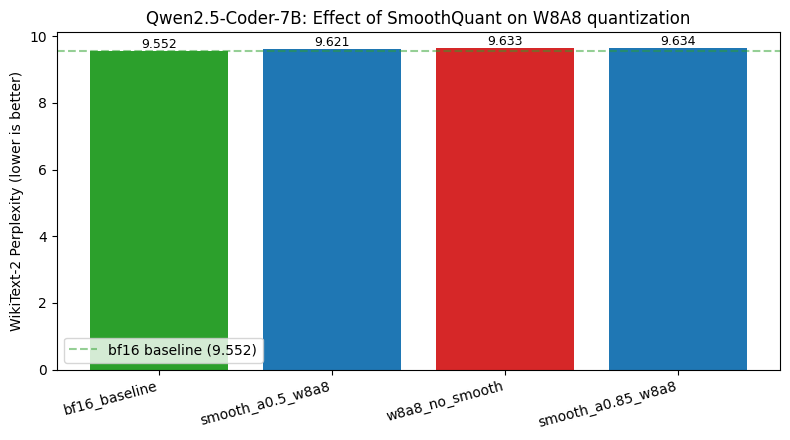

In [12]:
# Bar plot for the writeup
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = df['config'].tolist()
values = df['perplexity'].tolist()
colors = ['tab:green' if 'bf16' in c else 'tab:red' if 'no_smooth' in c else 'tab:blue'
          for c in labels]

bars = ax.bar(labels, values, color=colors)
ax.axhline(ppl_bf16, linestyle='--', color='tab:green', alpha=0.5,
           label=f'bf16 baseline ({ppl_bf16:.3f})')
ax.set_ylabel('WikiText-2 Perplexity (lower is better)')
ax.set_title(f'Qwen2.5-Coder-{MODEL_SIZE}: Effect of SmoothQuant on W8A8 quantization')
ax.legend()
plt.xticks(rotation=15, ha='right')

# Annotate each bar with its value
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'results/plots/ppl_comparison_{MODEL_SIZE.lower()}.png', dpi=120, bbox_inches='tight')
plt.show()

## What you should see

The specific numbers depend on the model but the **ordering** should be:

```
bf16_baseline        <  smooth_a0.5_w8a8  ≈  smooth_a0.85_w8a8   <<   w8a8_no_smooth
```

Typical magnitudes for Qwen2.5-Coder on WikiText-2:

| Config | Expected PPL (ballpark) |
|---|---|
| bf16 baseline | 5.5 – 6.5 |
| W8A8, no smoothing | 6.0 – 7.5 |
| SmoothQuant(0.5) + W8A8 | within 0.1 of bf16 |
| SmoothQuant(0.85) + W8A8 | within 0.1–0.2 of bf16 |

**If naive W8A8 is actually fine** (gap < 0.1 PPL vs bf16), that's a surprising-but-publishable finding: Qwen2.5-Coder may not have severe activation outliers. Save these numbers and move on; SmoothQuant will still probably help on downstream code benchmarks where precision matters more.

**If smoothed W8A8 is worse than naive W8A8**, something is wrong — most likely the act_scales are mis-keyed relative to the module paths in `smooth_qwen2`. Re-check that `act_scales` keys look like `model.layers.0.self_attn.q_proj` (not e.g. `layers.0.self_attn.q_proj` without the leading `model.`).

## Artifacts produced

After this notebook runs successfully:
- `results/ppl_<size>.csv` — perplexity numbers, ready to paste into the report
- `results/plots/ppl_comparison_<size>.png` — bar chart for the slide deck
- `checkpoints/qwen25-coder-<size>-smoothed-a0.5/` — smoothed bf16 weights in HF format. **This is what notebooks 03, 04, and 05 will load.**

## Next

→ `03_llmcompressor_export.ipynb` — converts the smoothed bf16 checkpoint into a vLLM-compatible W8A8 checkpoint with real INT8 kernels. This gives us actual speedup numbers for the profiling notebook and actual W8A8 inference for the benchmarks.